# Standalone figure builder: IV Δ anomR + LAI/Aridity

This notebook follows the standalone style and focuses on IV-derived ASCL4 `Δ anomR`.
It:
1. Loads `Rdiff_DAv8_M36_cd_minus_OLv8_M36_cd_ASCL4.mat`.
2. Maps `Δ anomR`.
3. Maps mean annual LAI and Aridity Index.
4. Builds box-and-whisker plots of `Δ anomR` by LAI and Aridity bins.



In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import xarray as xr
import scipy.io as sio
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap


def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / '.git').exists():
            return p
    return start


here = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
repo_root = find_repo_root(here)
sys.path.append(str(repo_root / 'common' / 'python' / 'plotting'))

from geospatial_plotting import REGION_BOUNDS, load_ease_grid, build_ease_grid_mapping

# Figure output helper
if 'SAVE_DIR' not in globals():
    from itertools import count
    SAVE_DIR = Path('paper_figures')
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    _fig_counter = count(1)

    def save_fig(fig, name=None):
        idx = next(_fig_counter)
        base = name if name is not None else f"figure_{idx}"
        fig.savefig(SAVE_DIR / f"{base}.png", dpi=300, bbox_inches='tight', pad_inches=0.04)
        fig.savefig(SAVE_DIR / f"{base}.pdf", bbox_inches='tight', pad_inches=0.04)
        return base



In [2]:
# ------------------------------
# 1) Paths / config
# ------------------------------
DEFAULT_DATA_DIR = Path('/Users/amfox/Desktop/GEOSldas_diagnostics/test_data')
DATA_DIR = Path(globals().get('DATA_DIR', DEFAULT_DATA_DIR))

iv_file = DATA_DIR / 'CYGNSS_Experiments/Evaluation/IVs/Rdiff_DAv8_M36_cd_minus_OLv8_M36_cd_ASCL4.mat'
ai_lai_file = DATA_DIR / 'CYGNSS_Experiments/Evaluation/IVs/aridity_indices_model_net_rad_20180801_20240630.nc4'

print(f'DATA_DIR: {DATA_DIR}')
print(f'IV file: {iv_file}')
print(f'AI/LAI file: {ai_lai_file}')

if not iv_file.exists():
    raise FileNotFoundError(f'Missing IV file: {iv_file}')
if not ai_lai_file.exists():
    raise FileNotFoundError(f'Missing AI/LAI file: {ai_lai_file}')



DATA_DIR: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data
IV file: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/CYGNSS_Experiments/Evaluation/IVs/Rdiff_DAv8_M36_cd_minus_OLv8_M36_cd_ASCL4.mat
AI/LAI file: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/CYGNSS_Experiments/Evaluation/IVs/aridity_indices_model_net_rad_20180801_20240630.nc4


In [3]:
# ------------------------------
# 2) Load IV Δ anomR (ASCL4)
# ------------------------------
mat = sio.loadmat(iv_file)

required = ['Rdiff_vector', 'lons', 'lats']
for k in required:
    if k not in mat:
        raise KeyError(f"Missing '{k}' in {iv_file}")

rdiff = np.asarray(mat['Rdiff_vector']).squeeze().astype(float)
lon_iv = np.asarray(mat['lons']).squeeze().astype(float)
lat_iv = np.asarray(mat['lats']).squeeze().astype(float)

if not (rdiff.size == lon_iv.size == lat_iv.size):
    raise ValueError(
        f'Size mismatch: Rdiff={rdiff.size}, lon={lon_iv.size}, lat={lat_iv.size}'
    )

print(f'Loaded IV points: {rdiff.size:,}')
print(f'Δ anomR mean ± std: {np.nanmean(rdiff):.4f} ± {np.nanstd(rdiff):.4f}')



Loaded IV points: 391,384
Δ anomR mean ± std: 0.0115 ± 0.0479


In [4]:
# ------------------------------
# 3) Load LAI + Aridity fields
# ------------------------------
ds = xr.open_dataset(ai_lai_file, decode_times=True)

ai = np.asarray(ds['AI_clim'].values).squeeze().astype(float)
lai = np.asarray(ds['mean_lai_clim'].values).squeeze().astype(float)
lon_ai = np.asarray(ds['lon'].isel(time=1).values).squeeze().astype(float)
lat_ai = np.asarray(ds['lat'].isel(time=1).values).squeeze().astype(float)

print(f'AI/LAI points: {ai.size:,}')



AI/LAI points: 70,773


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_55854/276417966.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rdiff_cmap = get_cmap('RdBu', len(rdiff_edges) - 1)
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_55854/276417966.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  lai_cmap = get_cmap('YlGn', len(lai_edges) - 1)
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_55854/276417966.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cm

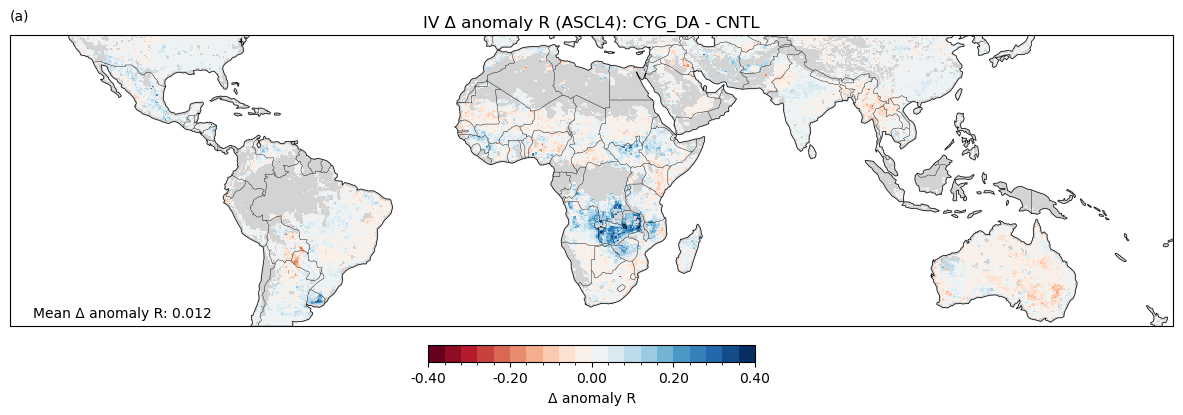

/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


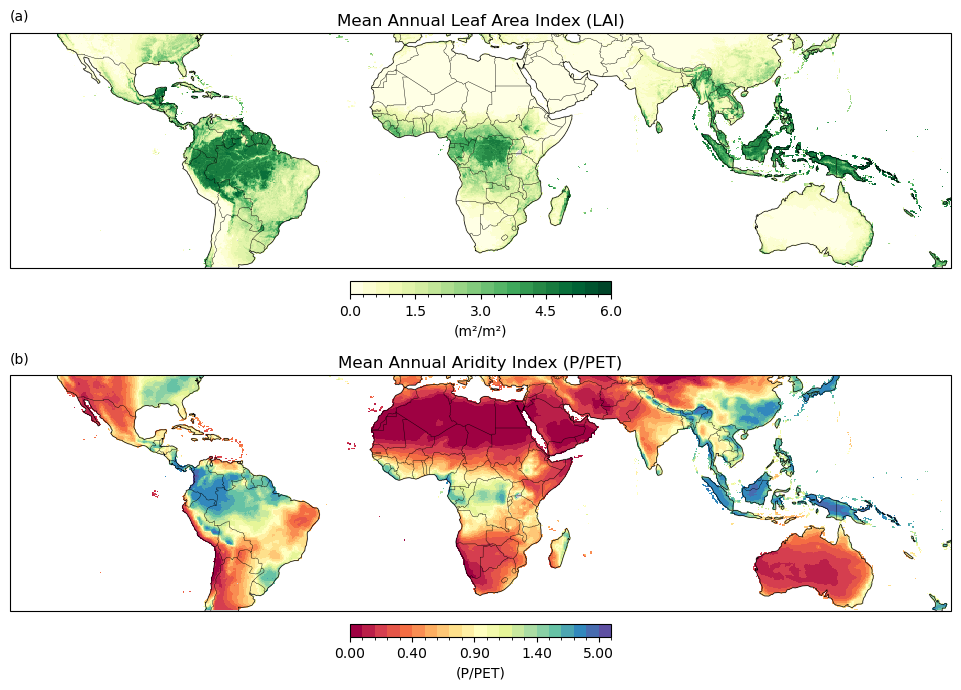

In [5]:
# ------------------------------
# 4) Maps: (A) Δ anomR, (B) predictors (LAI + Aridity)
# ------------------------------
lats_ease, lons_ease = load_ease_grid()
lats_row, lons_col = lats_ease[:, 1], lons_ease[1, :]
lon_grid, lat_grid = np.meshgrid(lons_col, lats_row)


def to_grid(values, lon_in, lat_in):
    arr = np.column_stack([values.flatten(), lon_in.flatten(), lat_in.flatten()])
    return build_ease_grid_mapping(arr, lats_row, lons_col)

rdiff_grid = to_grid(rdiff, lon_iv, lat_iv)
lai_grid = to_grid(lai, lon_ai, lat_ai)
ai_grid = to_grid(ai, lon_ai, lat_ai)

# Color settings
rdiff_vmin, rdiff_vmax = -0.4, 0.4
rdiff_edges = np.linspace(rdiff_vmin, rdiff_vmax, 21)
rdiff_cmap = get_cmap('RdBu', len(rdiff_edges) - 1)

lai_edges = np.linspace(0.0, 6.0, 21)
lai_cmap = get_cmap('YlGn', len(lai_edges) - 1)

ai_edges = np.array([0.00, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80,
                     0.90, 1.00, 1.10, 1.20, 1.30, 1.40, 1.50, 1.75, 2.00, 3.00, 5.00, 10.00])
ai_cmap = get_cmap('Spectral', len(ai_edges) - 1)

# ---------------------------------
# Figure A: standalone Δ anomR map
# ---------------------------------
fig_a, ax = plt.subplots(1, 1, figsize=(12, 4), subplot_kw={'projection': ccrs.PlateCarree()})

sc = ax.pcolormesh(
    lon_grid, lat_grid, rdiff_grid,
    cmap=rdiff_cmap,
    norm=BoundaryNorm(rdiff_edges, rdiff_cmap.N),
    transform=ccrs.PlateCarree()
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, color='lightgray', zorder=0)
ax.set_extent(REGION_BOUNDS['cygnss'], crs=ccrs.PlateCarree())
ax.set_title('IV Δ anomaly R (ASCL4): CYG_DA - CNTL')
mean_rdiff = float(np.nanmean(rdiff))
ax.text(
    0.02, 0.02, f'Mean Δ anomaly R: {mean_rdiff:.3f}',
    transform=ax.transAxes,
    va='bottom', ha='left',
    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.25')
)
ax.text(0.0, 1.04, '(a)', transform=ax.transAxes, va='bottom', ha='left')
ax.tick_params(labelbottom=False, labelleft=False)

cbar = fig_a.colorbar(sc, ax=ax, orientation='horizontal', pad=0.06, fraction=0.05)
cbar.set_label('Δ anomaly R')
cbar.set_ticks(rdiff_edges[::5])
cbar.ax.set_xticklabels([f"{t:.2f}" for t in rdiff_edges[::5]])

plt.tight_layout()
# save_fig(plt.gcf(), 'figure_IV_anomR_map')
plt.show()

# -------------------------------------------
# Figure B: predictors map (2x1, LAI+Aridity)
# -------------------------------------------
fig_b, axes = plt.subplots(2, 1, figsize=(12, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# (a) LAI
ax0 = axes[0]
sc0 = ax0.pcolormesh(
    lon_grid, lat_grid, lai_grid,
    cmap=lai_cmap,
    norm=BoundaryNorm(lai_edges, lai_cmap.N),
    transform=ccrs.PlateCarree()
)
ax0.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax0.add_feature(cfeature.BORDERS, linewidth=0.3)
ax0.add_feature(cfeature.LAND, color='lightgray', zorder=0)
ax0.set_extent(REGION_BOUNDS['cygnss'], crs=ccrs.PlateCarree())
ax0.set_title('Mean Annual Leaf Area Index (LAI)')
ax0.text(0.0, 1.04, '(a)', transform=ax0.transAxes, va='bottom', ha='left')
ax0.tick_params(labelbottom=False, labelleft=False)

cbar0 = fig_b.colorbar(sc0, ax=ax0, orientation='horizontal', pad=0.05, fraction=0.05)
cbar0.set_label('(m²/m²)')
cbar0.set_ticks(lai_edges[::5])
cbar0.ax.set_xticklabels([f"{t:.1f}" for t in lai_edges[::5]])

# (b) Aridity
ax1 = axes[1]
sc1 = ax1.pcolormesh(
    lon_grid, lat_grid, ai_grid,
    cmap=ai_cmap,
    norm=BoundaryNorm(ai_edges, ai_cmap.N),
    transform=ccrs.PlateCarree()
)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.3)
ax1.add_feature(cfeature.LAND, color='lightgray', zorder=0)
ax1.set_extent(REGION_BOUNDS['cygnss'], crs=ccrs.PlateCarree())
ax1.set_title('Mean Annual Aridity Index (P/PET)')
ax1.text(0.0, 1.04, '(b)', transform=ax1.transAxes, va='bottom', ha='left')
ax1.tick_params(labelbottom=False, labelleft=False)

cbar1 = fig_b.colorbar(sc1, ax=ax1, orientation='horizontal', pad=0.05, fraction=0.05, boundaries=ai_edges)
cbar1.set_label('(P/PET)')
pos = ai_edges[::5]
cbar1.set_ticks(pos)
cbar1.ax.set_xticklabels([f"{t:.2f}" for t in pos])

plt.tight_layout()
# save_fig(plt.gcf(), 'figure_IV_predictors_LAI_aridity_maps')
plt.show()





In [6]:
# ------------------------------
# 5) Align Δ anomR to AI/LAI grid via KDTree
# ------------------------------
iv_pts = np.column_stack((lon_iv.ravel(), lat_iv.ravel()))
pred_pts = np.column_stack((lon_ai.ravel(), lat_ai.ravel()))

kdtree = cKDTree(iv_pts)
dists, idx = kdtree.query(pred_pts, k=1)

delta_on_pred = rdiff[idx]
lai_vec = lai.ravel()
ai_vec = ai.ravel()

# Mask finite values only
valid = np.isfinite(delta_on_pred) & np.isfinite(lai_vec) & np.isfinite(ai_vec)

delta_use = delta_on_pred[valid]
lai_use = lai_vec[valid]
ai_use = ai_vec[valid]

print(f'Valid paired samples for boxplots: {delta_use.size:,}')
print(f'Nearest-neighbor distance median/max (deg): {np.nanmedian(dists):.5f} / {np.nanmax(dists):.5f}')



Valid paired samples for boxplots: 41,557
Nearest-neighbor distance median/max (deg): 0.00004 / 0.00008


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_55854/151838334.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(lai_data, labels=lai_labels, showfliers=True, flierprops={'markersize': 3, 'marker': 'o'})
/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_55854/151838334.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(ai_data, labels=ai_labels, showfliers=True, flierprops={'markersize': 3, 'marker': 'o'})


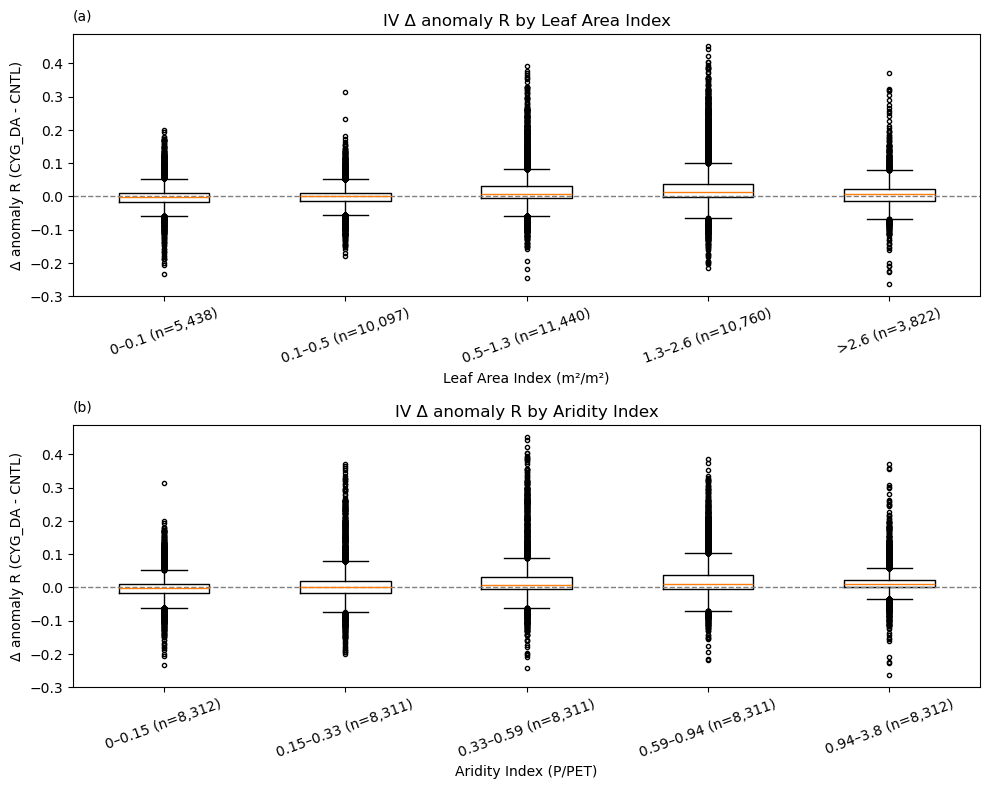

In [7]:
# ------------------------------
# 6) Box-and-whisker: Δ anomR by LAI and Aridity
# ------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# (a) LAI bins (fixed bins)
lai_bins = [0.0, 0.10, 0.50, 1.30, 2.60, np.inf]
df_lai = pd.DataFrame({'lai': lai_use, 'delta_anomR': delta_use}).replace([np.inf, -np.inf], np.nan).dropna()
df_lai['bin'] = pd.cut(df_lai['lai'], bins=lai_bins, include_lowest=True)

lai_data = []
lai_labels = []
for lbl in df_lai['bin'].cat.categories:
    vals = df_lai.loc[df_lai['bin'] == lbl, 'delta_anomR'].dropna().values
    left = max(0, lbl.left)
    right = lbl.right if lbl.right != float('inf') else np.inf
    lab = f"{left:.2g}–{right:.2g}" if right != np.inf else f">{left:.2g}"
    lai_data.append(vals)
    lai_labels.append(f"{lab} (n={len(vals):,})")

axes[0].boxplot(lai_data, labels=lai_labels, showfliers=True, flierprops={'markersize': 3, 'marker': 'o'})
axes[0].axhline(0, ls='--', lw=1, color='gray')
axes[0].set_title('IV Δ anomaly R by Leaf Area Index')
axes[0].set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
axes[0].set_xlabel('Leaf Area Index (m²/m²)')
for tick in axes[0].get_xticklabels():
    tick.set_rotation(20)
axes[0].text(0.0, 1.04, '(a)', transform=axes[0].transAxes, va='bottom', ha='left')

# (b) Aridity bins (quintiles)
df_ai = pd.DataFrame({'ai': ai_use, 'delta_anomR': delta_use}).replace([np.inf, -np.inf], np.nan).dropna()
try:
    df_ai['bin'] = pd.qcut(df_ai['ai'], q=5, duplicates='drop')
except Exception:
    df_ai['bin'] = pd.cut(df_ai['ai'], bins=5)

ai_data = []
ai_labels = []
for lbl in df_ai['bin'].cat.categories:
    vals = df_ai.loc[df_ai['bin'] == lbl, 'delta_anomR'].dropna().values
    left = max(0, lbl.left)
    right = lbl.right if lbl.right != float('inf') else np.inf
    lab = f"{left:.2g}–{right:.2g}" if right != np.inf else f">{left:.2g}"
    ai_data.append(vals)
    ai_labels.append(f"{lab} (n={len(vals):,})")

axes[1].boxplot(ai_data, labels=ai_labels, showfliers=True, flierprops={'markersize': 3, 'marker': 'o'})
axes[1].axhline(0, ls='--', lw=1, color='gray')
axes[1].set_title('IV Δ anomaly R by Aridity Index')
axes[1].set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
axes[1].set_xlabel('Aridity Index (P/PET)')
for tick in axes[1].get_xticklabels():
    tick.set_rotation(20)
axes[1].text(0.0, 1.04, '(b)', transform=axes[1].transAxes, va='bottom', ha='left')

plt.tight_layout()
# save_fig(plt.gcf(), 'figure_IV_anomR_boxplots_lai_aridity')
plt.show()



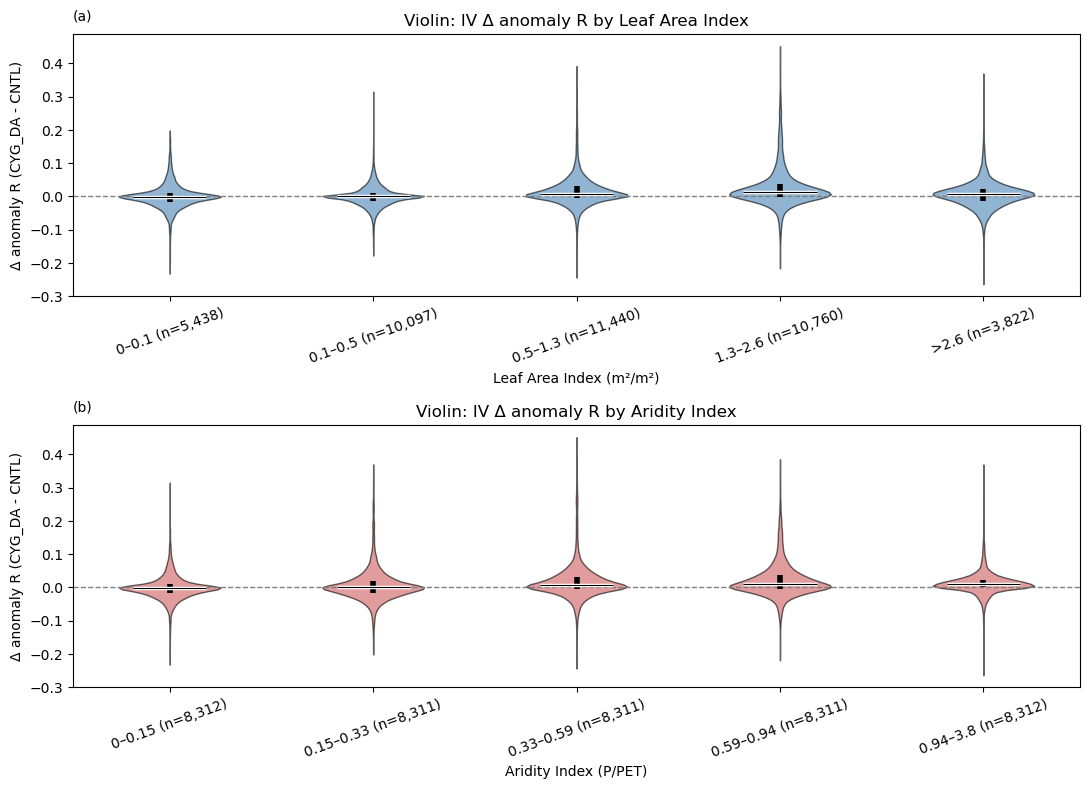

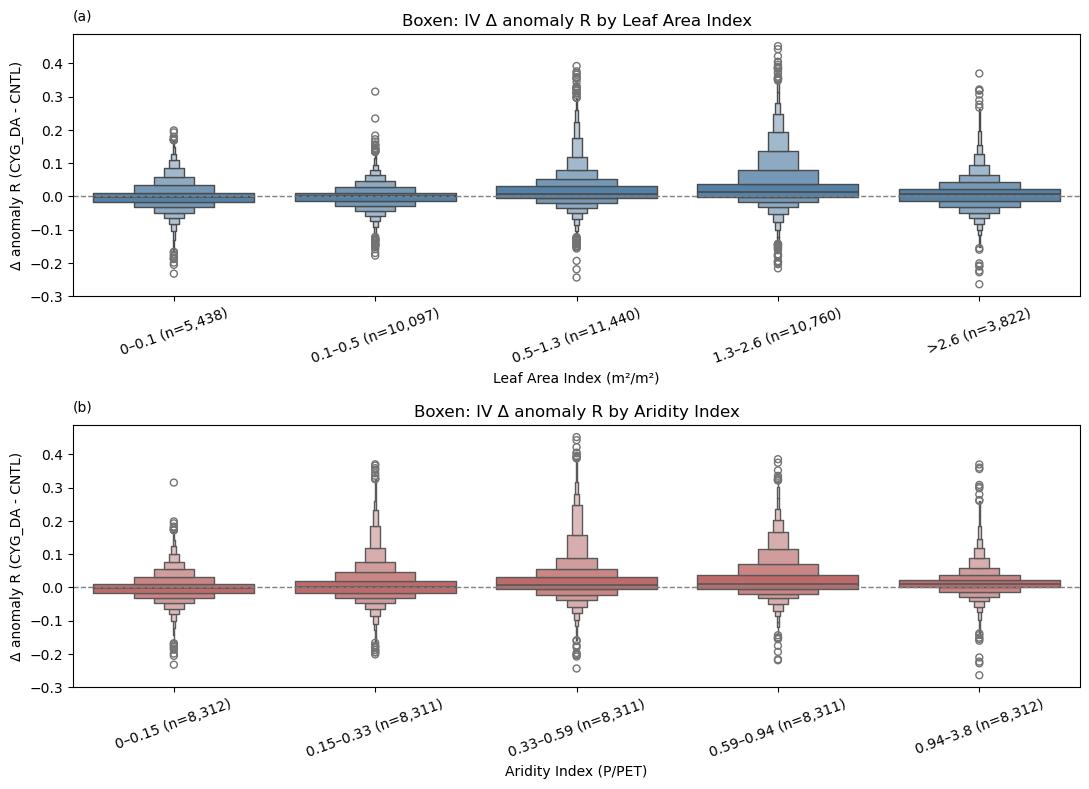

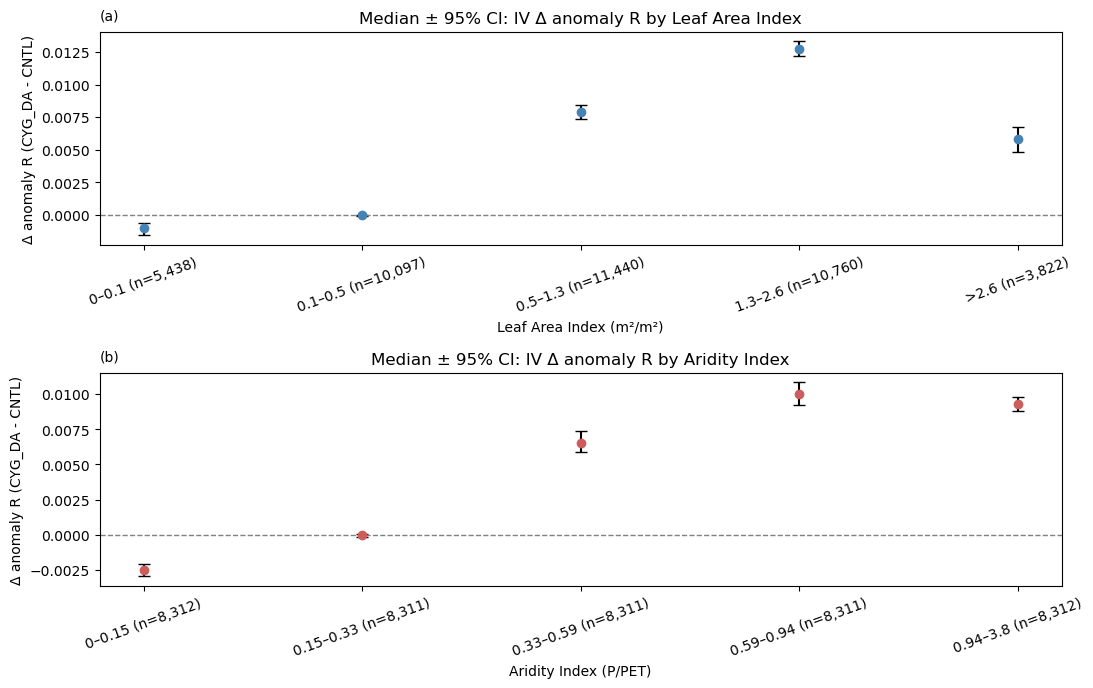

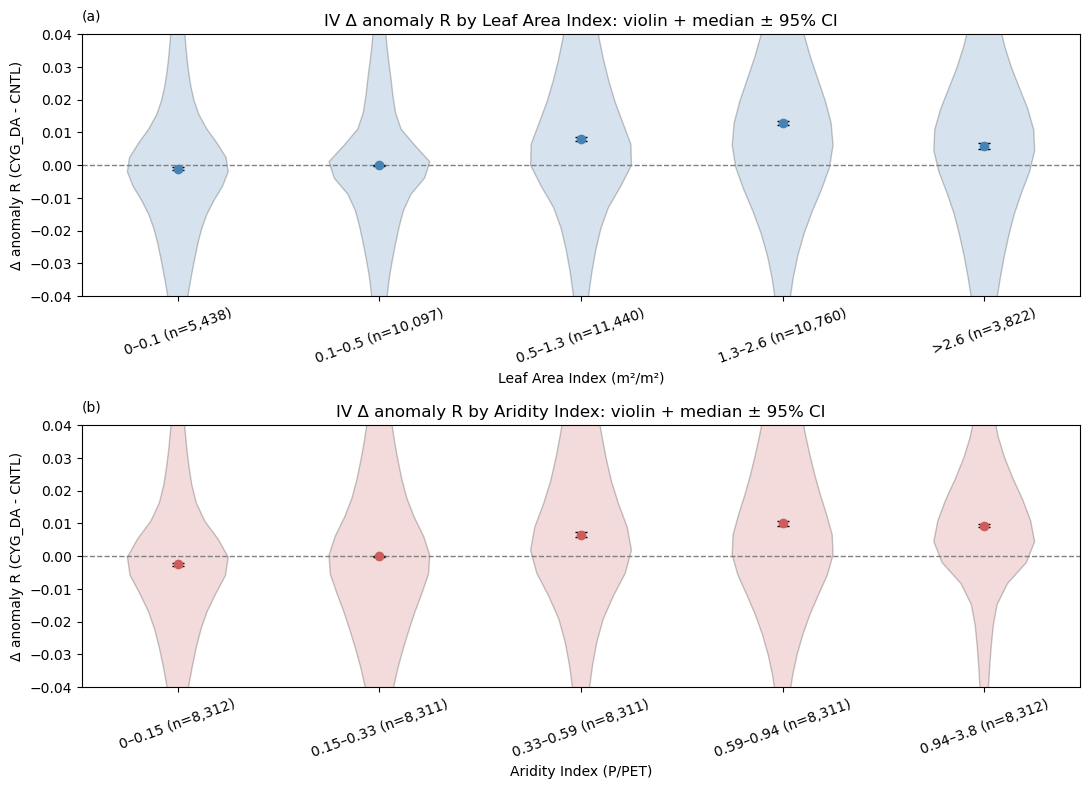

In [8]:
# ------------------------------
# 7) Alternative distribution views for Δ anomR
#     (Violin + median/IQR, and Boxen)
# ------------------------------
import seaborn as sns

# Rebuild the same LAI/aridity binning used by the boxplots above

def _bin_label(interval):
    left = max(0.0, float(interval.left))
    right = float(interval.right)
    if np.isinf(right):
        return f">{left:.2g}"
    return f"{left:.2g}–{right:.2g}"

# LAI bins (fixed)
lai_bins = [0.0, 0.10, 0.50, 1.30, 2.60, np.inf]
df_lai_alt = (
    pd.DataFrame({'lai': lai_use, 'delta_anomR': delta_use})
      .replace([np.inf, -np.inf], np.nan)
      .dropna(subset=['lai', 'delta_anomR'])
)
df_lai_alt['bin'] = pd.cut(df_lai_alt['lai'], bins=lai_bins, include_lowest=True)
lai_order = list(df_lai_alt['bin'].cat.categories)
lai_counts = df_lai_alt['bin'].value_counts().reindex(lai_order).fillna(0).astype(int)
lai_label_map = {b: _bin_label(b) for b in lai_order}
lai_label_n_map = {b: f"{_bin_label(b)} (n={lai_counts[b]:,})" for b in lai_order}
df_lai_alt['bin_label_n'] = df_lai_alt['bin'].map(lai_label_n_map)
lai_order_labels = [lai_label_n_map[b] for b in lai_order]
lai_data = [df_lai_alt.loc[df_lai_alt['bin'] == b, 'delta_anomR'].values for b in lai_order]

# Aridity bins (quintiles, same logic as earlier)
df_ai_alt = (
    pd.DataFrame({'ai': ai_use, 'delta_anomR': delta_use})
      .replace([np.inf, -np.inf], np.nan)
      .dropna(subset=['ai', 'delta_anomR'])
)
try:
    df_ai_alt['bin'] = pd.qcut(df_ai_alt['ai'], q=5, duplicates='drop')
except Exception:
    df_ai_alt['bin'] = pd.cut(df_ai_alt['ai'], bins=5)

ai_order = list(df_ai_alt['bin'].cat.categories)
ai_counts = df_ai_alt['bin'].value_counts().reindex(ai_order).fillna(0).astype(int)
ai_label_map = {b: _bin_label(b) for b in ai_order}
ai_label_n_map = {b: f"{_bin_label(b)} (n={ai_counts[b]:,})" for b in ai_order}
df_ai_alt['bin_label_n'] = df_ai_alt['bin'].map(ai_label_n_map)
ai_order_labels = [ai_label_n_map[b] for b in ai_order]
ai_data = [df_ai_alt.loc[df_ai_alt['bin'] == b, 'delta_anomR'].values for b in ai_order]

# ------------------------------
# Figure A: Violin plots + median/IQR overlay
# ------------------------------
fig_v, axes_v = plt.subplots(2, 1, figsize=(11, 8))

# (a) LAI violin
ax = axes_v[0]
parts = ax.violinplot(lai_data, showmeans=False, showmedians=False, showextrema=False)
for body in parts['bodies']:
    body.set_facecolor('steelblue')
    body.set_edgecolor('black')
    body.set_alpha(0.6)

for i, vals in enumerate(lai_data, start=1):
    if len(vals) == 0:
        continue
    q1, med, q3 = np.nanpercentile(vals, [25, 50, 75])
    ax.vlines(i, q1, q3, color='k', lw=4, zorder=3)
    ax.hlines(med, i - 0.18, i + 0.18, color='white', lw=2.5, zorder=4)
    ax.hlines(med, i - 0.18, i + 0.18, color='k', lw=0.8, zorder=5)

ax.axhline(0, ls='--', lw=1, color='gray')
ax.set_xticks(range(1, len(lai_order_labels) + 1))
ax.set_xticklabels(lai_order_labels, rotation=20)
ax.set_title('Violin: IV Δ anomaly R by Leaf Area Index')
ax.set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
ax.set_xlabel('Leaf Area Index (m²/m²)')
ax.text(0.0, 1.04, '(a)', transform=ax.transAxes, va='bottom', ha='left')

# (b) Aridity violin
ax = axes_v[1]
parts = ax.violinplot(ai_data, showmeans=False, showmedians=False, showextrema=False)
for body in parts['bodies']:
    body.set_facecolor('indianred')
    body.set_edgecolor('black')
    body.set_alpha(0.6)

for i, vals in enumerate(ai_data, start=1):
    if len(vals) == 0:
        continue
    q1, med, q3 = np.nanpercentile(vals, [25, 50, 75])
    ax.vlines(i, q1, q3, color='k', lw=4, zorder=3)
    ax.hlines(med, i - 0.18, i + 0.18, color='white', lw=2.5, zorder=4)
    ax.hlines(med, i - 0.18, i + 0.18, color='k', lw=0.8, zorder=5)

ax.axhline(0, ls='--', lw=1, color='gray')
ax.set_xticks(range(1, len(ai_order_labels) + 1))
ax.set_xticklabels(ai_order_labels, rotation=20)
ax.set_title('Violin: IV Δ anomaly R by Aridity Index')
ax.set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
ax.set_xlabel('Aridity Index (P/PET)')
ax.text(0.0, 1.04, '(b)', transform=ax.transAxes, va='bottom', ha='left')

plt.tight_layout()
# save_fig(plt.gcf(), 'figure_IV_anomR_violin_lai_aridity')
plt.show()

# ------------------------------
# Figure B: Boxen plots (letter-value)
# ------------------------------
fig_bx, axes_bx = plt.subplots(2, 1, figsize=(11, 8))

sns.boxenplot(
    data=df_lai_alt,
    x='bin_label_n', y='delta_anomR',
    order=lai_order_labels,
    color='steelblue',
    k_depth='proportion',
    linewidth=1,
    ax=axes_bx[0]
)
axes_bx[0].axhline(0, ls='--', lw=1, color='gray')
axes_bx[0].set_title('Boxen: IV Δ anomaly R by Leaf Area Index')
axes_bx[0].set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
axes_bx[0].set_xlabel('Leaf Area Index (m²/m²)')
axes_bx[0].tick_params(axis='x', rotation=20)
axes_bx[0].text(0.0, 1.04, '(a)', transform=axes_bx[0].transAxes, va='bottom', ha='left')

sns.boxenplot(
    data=df_ai_alt,
    x='bin_label_n', y='delta_anomR',
    order=ai_order_labels,
    color='indianred',
    k_depth='proportion',
    linewidth=1,
    ax=axes_bx[1]
)
axes_bx[1].axhline(0, ls='--', lw=1, color='gray')
axes_bx[1].set_title('Boxen: IV Δ anomaly R by Aridity Index')
axes_bx[1].set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
axes_bx[1].set_xlabel('Aridity Index (P/PET)')
axes_bx[1].tick_params(axis='x', rotation=20)
axes_bx[1].text(0.0, 1.04, '(b)', transform=axes_bx[1].transAxes, va='bottom', ha='left')

plt.tight_layout()
# save_fig(plt.gcf(), 'figure_IV_anomR_boxen_lai_aridity')
plt.show()


# ------------------------------
# Figure C: Bin median ± 95% CI (no distribution shape)
# ------------------------------
def _median_ci_boot(vals, n_boot=2000, seed=42):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    n = vals.size
    if n == 0:
        return np.nan, np.nan, np.nan
    med = float(np.nanmedian(vals))
    if n == 1:
        return med, med, med
    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        samp = vals[rng.integers(0, n, size=n)]
        boots[b] = np.nanmedian(samp)
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return med, float(lo), float(hi)

fig_ci, axes_ci = plt.subplots(2, 1, figsize=(11, 7))

# (a) LAI: median ± 95% CI
lai_stats = [_median_ci_boot(v, n_boot=2000, seed=42 + i) for i, v in enumerate(lai_data)]
lai_medians = np.array([s[0] for s in lai_stats], dtype=float)
lai_lows = np.array([s[1] for s in lai_stats], dtype=float)
lai_highs = np.array([s[2] for s in lai_stats], dtype=float)
x_lai = np.arange(1, len(lai_order_labels) + 1)

yerr_lai = np.vstack([lai_medians - lai_lows, lai_highs - lai_medians])
axes_ci[0].errorbar(x_lai, lai_medians, yerr=yerr_lai, fmt='o', color='steelblue', ecolor='black', capsize=4, lw=1.5)
axes_ci[0].axhline(0, ls='--', lw=1, color='gray')
axes_ci[0].set_xticks(x_lai)
axes_ci[0].set_xticklabels(lai_order_labels, rotation=20)
axes_ci[0].set_title('Median ± 95% CI: IV Δ anomaly R by Leaf Area Index')
axes_ci[0].set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
axes_ci[0].set_xlabel('Leaf Area Index (m²/m²)')
axes_ci[0].text(0.0, 1.04, '(a)', transform=axes_ci[0].transAxes, va='bottom', ha='left')

# (b) Aridity: median ± 95% CI
ai_stats = [_median_ci_boot(v, n_boot=2000, seed=142 + i) for i, v in enumerate(ai_data)]
ai_medians = np.array([s[0] for s in ai_stats], dtype=float)
ai_lows = np.array([s[1] for s in ai_stats], dtype=float)
ai_highs = np.array([s[2] for s in ai_stats], dtype=float)
x_ai = np.arange(1, len(ai_order_labels) + 1)

yerr_ai = np.vstack([ai_medians - ai_lows, ai_highs - ai_medians])
axes_ci[1].errorbar(x_ai, ai_medians, yerr=yerr_ai, fmt='o', color='indianred', ecolor='black', capsize=4, lw=1.5)
axes_ci[1].axhline(0, ls='--', lw=1, color='gray')
axes_ci[1].set_xticks(x_ai)
axes_ci[1].set_xticklabels(ai_order_labels, rotation=20)
axes_ci[1].set_title('Median ± 95% CI: IV Δ anomaly R by Aridity Index')
axes_ci[1].set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
axes_ci[1].set_xlabel('Aridity Index (P/PET)')
axes_ci[1].text(0.0, 1.04, '(b)', transform=axes_ci[1].transAxes, va='bottom', ha='left')

plt.tight_layout()
# save_fig(plt.gcf(), 'figure_IV_anomR_median_ci_lai_aridity')
plt.show()


# ------------------------------
# Figure D: Violin background + median ± 95% CI (fixed y-limits)
# ------------------------------
fig_mix, axes_mix = plt.subplots(2, 1, figsize=(11, 8))

# (a) LAI panel
ax = axes_mix[0]
parts = ax.violinplot(lai_data, showmeans=False, showmedians=False, showextrema=False)
for body in parts['bodies']:
    body.set_facecolor('steelblue')
    body.set_edgecolor('black')
    body.set_alpha(0.22)

lai_stats_m = [_median_ci_boot(v, n_boot=2000, seed=242 + i) for i, v in enumerate(lai_data)]
lai_med = np.array([s[0] for s in lai_stats_m], dtype=float)
lai_lo = np.array([s[1] for s in lai_stats_m], dtype=float)
lai_hi = np.array([s[2] for s in lai_stats_m], dtype=float)
x_lai = np.arange(1, len(lai_order_labels) + 1)
yerr_lai = np.vstack([lai_med - lai_lo, lai_hi - lai_med])

ax.errorbar(x_lai, lai_med, yerr=yerr_lai, fmt='o', color='steelblue', ecolor='black', capsize=4, elinewidth=1.5, lw=1.3, zorder=5)
ax.axhline(0, ls='--', lw=1, color='gray')
ax.set_xticks(x_lai)
ax.set_xticklabels(lai_order_labels, rotation=20)
ax.set_ylim(-0.04, 0.04)
ax.set_title('IV Δ anomaly R by Leaf Area Index: violin + median ± 95% CI')
ax.set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
ax.set_xlabel('Leaf Area Index (m²/m²)')
ax.text(0.0, 1.04, '(a)', transform=ax.transAxes, va='bottom', ha='left')

# (b) Aridity panel
ax = axes_mix[1]
parts = ax.violinplot(ai_data, showmeans=False, showmedians=False, showextrema=False)
for body in parts['bodies']:
    body.set_facecolor('indianred')
    body.set_edgecolor('black')
    body.set_alpha(0.22)

ai_stats_m = [_median_ci_boot(v, n_boot=2000, seed=342 + i) for i, v in enumerate(ai_data)]
ai_med = np.array([s[0] for s in ai_stats_m], dtype=float)
ai_lo = np.array([s[1] for s in ai_stats_m], dtype=float)
ai_hi = np.array([s[2] for s in ai_stats_m], dtype=float)
x_ai = np.arange(1, len(ai_order_labels) + 1)
yerr_ai = np.vstack([ai_med - ai_lo, ai_hi - ai_med])

ax.errorbar(x_ai, ai_med, yerr=yerr_ai, fmt='o', color='indianred', ecolor='black', capsize=4, elinewidth=1.5, lw=1.3, zorder=5)
ax.axhline(0, ls='--', lw=1, color='gray')
ax.set_xticks(x_ai)
ax.set_xticklabels(ai_order_labels, rotation=20)
ax.set_ylim(-0.04, 0.04)
ax.set_title('IV Δ anomaly R by Aridity Index: violin + median ± 95% CI')
ax.set_ylabel('Δ anomaly R (CYG_DA - CNTL)')
ax.set_xlabel('Aridity Index (P/PET)')
ax.text(0.0, 1.04, '(b)', transform=ax.transAxes, va='bottom', ha='left')

plt.tight_layout()
# save_fig(plt.gcf(), 'figure_IV_anomR_violin_median_ci_ylim005')
plt.show()


